# AIDS: intersectional bias analysis

**Goal:** Evaluating dataset viability to explore intersectional bias, finding elligible crossing between sensitive attributes and detecting baseline inbalances.

## Setup

AIDS dataset contains the following sensitive attributes: *homo*, *gender*, *race*, *age*. We need to evaluate how combinations of these experiments generate interesting results for intersectional bias. To view insights on the dataset variables: https://archive.ics.uci.edu/dataset/890/aids+clinical+trials+group+study+175

Some binary definitions in the dataset:

```
race: (0=White, 1=non-white)
gender: (0=F, 1=M)
homo: (0=no, 1=yes)
cid: censoring indicator (1 = failure, 0 = censoring)
```

In [30]:
import sys 
import os

sys.path.append(os.path.abspath("../utils"))
from config import DATA_PATH

DATASET_NAME = "AIDS"
# Target variable = censoring indicator (cid). 1 means death, 0 means censored
# already renamed cid to target in pre-processed table
TARGET_COL = "target"
FAVORABLE_LABEL = 0

# Sensitive attributes to evaluate
SENSITIVE_ATTRS = ["race", "gender", "homo"]

# Privileged subgroups
# In the context of this study, privileged groups comprise the majority of existing samples
PRIVILEGED =  {
    "gender": 1, # male
    "race": 0, # white
    "homo": 1 # yes
}

MIN_SUBGROUP_COUNT = 60

### Visual configurations

In [26]:
import warnings
warnings. filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sab

from scipy import stats
from scipy.stats import chi2_contingency

LAB_PALETTE_SEQUENTIAL = [
    "#f0f9fa", # Ice white (Almost white, close to no correlation)
    "#b2ebf2", # Acqua
    "#3eccc4", # Teal (signs start to show up)
    "#1a659e", # Light Blue (moderate association)
    "#002a61"  # Navy Blue (critical association)
]

# global seaborn configurations

sab.set_theme(style="whitegrid")
sab.set_palette(LAB_PALETTE_SEQUENTIAL)

# custom heatmap based on palette
LAB_CMAP = LinearSegmentedColormap.from_list("LabGradient", LAB_PALETTE_SEQUENTIAL)

# LAB_PALETTE_20 for high density (20 colors)
LAB_PALETTE_CATEGORICAL = [
    # NAVY (Higher privilege/status)
    "#001b3d", # Navy Ultra Dark
    "#002a61", # Original Navy
    "#004b8d", # Medium Navy
    "#006cc2", # Shiny Navy
    
    # BLUE (Upper intermediate groups)
    "#134e7a", # Deep Blue
    "#1a659e", # Original Blue
    "#4d8fc1", # Steel Blue
    "#82b4dc", # Sky Blue
    
    # PURPLE (Transition/ Intersection zones)
    "#2e2c8f", # Deep Purple
    "#403eb1", # Purple Original
    "#6b69d6", # Medium Purple
    "#8e8cf2", # Lavender 
    
    # TEAL (Parity groups)
    "#168275", # Deep Teal
    "#1eaf9d", # Teal Original
    "#28d1bd", # Bright Teal
    "#5fe3d3", # Mint Teal
    
    # AQUA (Higher vulnerability)
    "#2fa39d", # Dark Aqua
    "#3eccc4", # Aqua Original
    "#66cbe1", # Sky Blue Original
    "#b3b1ff"  # Pale Lavender (lightest point)
]

sab.set_palette(LAB_PALETTE_CATEGORICAL)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Functions
The statistic method used for this evaluation is the Wilson Score Interval. It performs better for smaller instance numbers, avoiding noise-generated bias in samples.

In [44]:
def wilson_ci(k, n, z=1.96):
    '''Wilson Score Interval'''
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    spread = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return float(center - spread), float(center + spread)

def subgroup_label_stats(df, subgroup_col, target_col, favorable_label):
    '''Calculates favorable rate and WCI for each subgroup'''
    records = []
    for sg, grp in df.groupby(subgroup_col):
        n = len(grp)
        k = (grp[target_col] == favorable_label).sum()
        rate = k / n if n > 0 else np.nan
        lo, hi = wilson_ci(k, n)
        records.append({
            "subgroup": sg, "n": n, "favorable_n": int(k),
            "favorable_rate": rate, "IC_low": lo, "IC_high": hi
        })
    return pd.DataFrame(records).sort_values("subgroup").reset_index(drop=True)

def cramers_v(df, col1, col2):
    '''Cramer's V - determines how strongly two attributes are associated'''
    ct = pd.crosstab(df[col1], df[col2])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0

print("✓ Done importing functions")

✓ Done importing functions


## Pre-Processing
A bit of pre-processing is already executed during the `init_datasets` notebook. This section takes care of any extra needed processing and visualization

In [13]:
processed_data_path = DATA_PATH / "processed"
df_pp = pd.read_csv(processed_data_path / f"6_aids_pp.csv")
# creating age-group category
bins = [0, 18, 34, 50, 65, 80]
labels = ['0-18', '19-34', '35-50', '51-65', '66-80']
df_pp['age_group'] = pd.cut(df_pp['age'], bins=bins, labels=labels, right=True)
df_pp.head(5)

,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,...,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,target,age_group
0,2,48,89.8128,0,0,0,100,0,0,1,...,1,0,1,0,422,477,566,324,0,35-50
1,3,61,49.4424,0,0,0,90,0,1,1,...,3,0,1,0,162,218,392,564,1,51-65
2,3,45,88.4520,0,1,1,90,0,1,1,...,3,0,1,1,326,274,2063,1893,0,35-50
3,3,47,85.2768,0,1,0,100,0,1,1,...,3,0,1,0,287,394,1590,966,0,35-50
4,0,43,66.6792,0,1,0,100,0,1,1,...,3,0,0,0,504,353,870,782,0,35-50


## Sensitive Attributes Inventory

In [14]:
SECONDARY_ATTRS = ["age_group"]
ALL_ANALYSIS_ATTRS = SENSITIVE_ATTRS + SECONDARY_ATTRS

for attr in ALL_ANALYSIS_ATTRS:
    print(f"  {attr} (type: {df_pp[attr].dtype})")

    # Calculating frequencies and proportions
    counts = df_pp[attr].value_counts().sort_index()
    percents = df_pp[attr].value_counts(normalize=True).sort_index() * 100

    # Formatting view
    for val, count in counts.items():
        pct = percents[val]
        print(f"    {str(val):<30} n={count:>6,}  ({pct:>5.1f}%)")
    print()

# Checking for null values
null_check = df_pp[ALL_ANALYSIS_ATTRS].isnull().sum().sum()
if null_check == 0:
    print(f"✓ Quality Check: No missing values in analysis attributes.")
else:
    print(f"⚠ Warning: Found {null_check} missing values.")


  race (type: int64)
    0                              n= 1,522  ( 71.2%)
    1                              n=   617  ( 28.8%)

  gender (type: int64)
    0                              n=   368  ( 17.2%)
    1                              n= 1,771  ( 82.8%)

  homo (type: int64)
    0                              n=   725  ( 33.9%)
    1                              n= 1,414  ( 66.1%)

  age_group (type: category)
    0-18                           n=    33  (  1.5%)
    19-34                          n= 1,053  ( 49.2%)
    35-50                          n=   950  ( 44.4%)
    51-65                          n=    95  (  4.4%)
    66-80                          n=     8  (  0.4%)

✓ Quality Check: No missing values in analysis attributes.


## Feasibility of Crossed Subgroup Samples

- Gender inbalance is as high as expected: 82.8% of men against 17.2% of women;
- In regards to race, the majority of samples are from white individuals (71.2%) against 28.8% non-white;
- There is also an lower inbalance seen in the proportions of homosexual activity being yes (1) or no (0): 66.1% yes and 33.9% no;
- Age groups from younger (0-18) and older individuals (51-80) represent only 6.3% of the sample proportions.

Experimenting with gender x race, homo x gender, homo x race, and maybe gender x homo x race could deliver interesting initial fairness experiments.

Creating contingency table with minimum n for each intersectional subgroup.

  INTERSECTIONAL VIABILITY SCANNER — AIDS
  Minimum Threshold (n): 60
  Total combinations tested: 3

Intersection Pair  Subgroups  Min N Viability (%)    Verdict
    race × gender          4    155        100.0%     FULL ✅
      race × homo          4    267        100.0%     FULL ✅
    gender × homo          4     11         75.0% PARTIAL ⚠️

✓ Analysis complete. Figure saved at: c:\Users\alice\Documents\TCC\intersectional-bias-fairness-healthcare\data\intersectional_analysis\AIDS_block2_viability_analysis.png


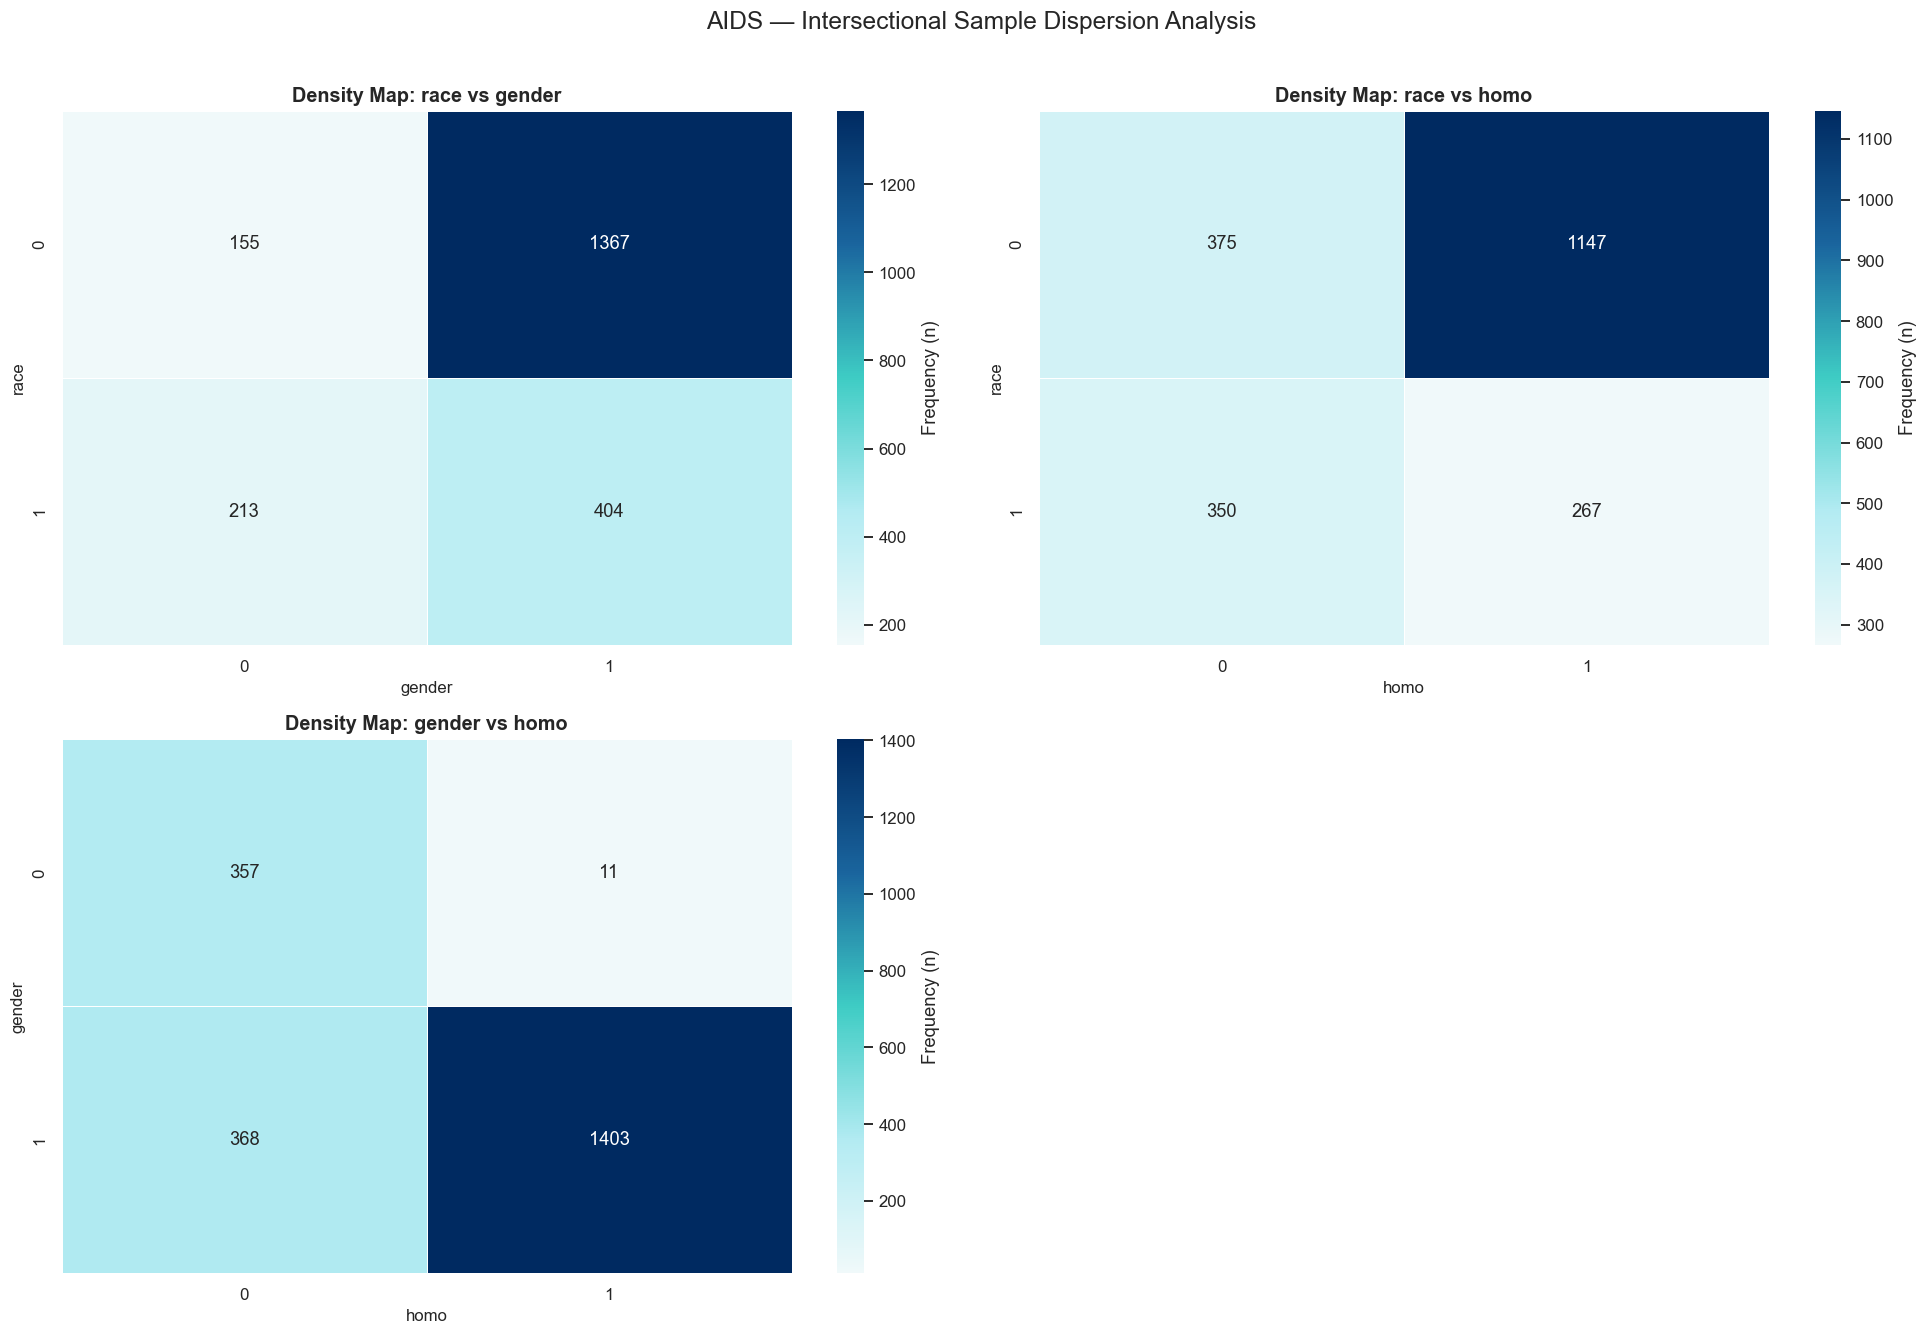

In [34]:
import itertools
import math
import os

# Exhaustive pair generation
# Identity intersections (sensitive x sensitive)
sens_pairs = list(itertools.combinations(SENSITIVE_ATTRS, 2))

print(f"{'='*75}")
print(f"  INTERSECTIONAL VIABILITY SCANNER — AIDS")
print(f"{'='*75}")
print(f"  Minimum Threshold (n): {MIN_SUBGROUP_COUNT}")
print(f"  Total combinations tested: {len(sens_pairs)}\n")

viability_records = []

for attr_a, attr_b in sens_pairs:
    # Cross-tabulation
    ct = pd.crosstab(df_pp[attr_a], df_pp[attr_b])

    total_subgroups = ct.size
    min_n_found= int(ct.values.min())

    # Viability Criterion: cells meeting the threshold
    viable_cells = (ct >= MIN_SUBGROUP_COUNT).sum().sum()
    viability_pct = (viable_cells / total_subgroups) * 100

    # Verdict definition
    if viability_pct == 100:
        verdict = "FULL ✅"
    elif viability_pct >= 50:
        verdict = "PARTIAL ⚠️"
    else:
        verdict = "CRITICAL ❌"

    viability_records.append({
        "Intersection Pair": f"{attr_a} × {attr_b}",
        "Subgroups": total_subgroups,
        "Min N": min_n_found,
        "Viability (%)": f"{viability_pct:.1f}%",
        "Verdict": verdict
    })

# Display Summary Table
summary_df = pd.DataFrame(viability_records)
print(summary_df.to_string(index=False))

# Visualization
plot_pairs = sens_pairs
n_plot = len(plot_pairs)
n_cols = 2
n_rows = math.ceil(n_plot / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()


for i, (attr_a, attr_b) in enumerate(plot_pairs):
    ct = pd.crosstab(df_pp[attr_a], df_pp[attr_b])
    
    # Heatmap using Lab Palette and Wilson-ready annotations
    sab.heatmap(ct, annot=True, fmt="d", cmap=LAB_CMAP, ax=axes[i], 
                linewidths=0.5, cbar_kws={"label": "Frequency (n)"})
    
    axes[i].set_title(f"Density Map: {attr_a} vs {attr_b}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel(attr_b, fontsize=11)
    axes[i].set_ylabel(attr_a, fontsize=11)

# Clean empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"{DATASET_NAME} — Intersectional Sample Dispersion Analysis", fontsize=16, y=1.01)
plt.tight_layout()

# ── 4. Automatic Figure Saving ─────────────────────────────────────────────
file_name = f"{DATASET_NAME.replace(' ','_')}_block2_viability_analysis.png"
save_path = DATA_PATH / f"intersectional_analysis/{file_name}"
plt.savefig(save_path, bbox_inches="tight", dpi=300)

print(f"\n✓ Analysis complete. Figure saved at: {save_path}")
plt.show()

### Label By Subgroup

  LABEL DISTRIBUTION ANALYSIS (cid = 1) — AIDS
  Global Favorable Rate: 0.2436 (24.36%)

✓ Visualization generated and saved: race x gender


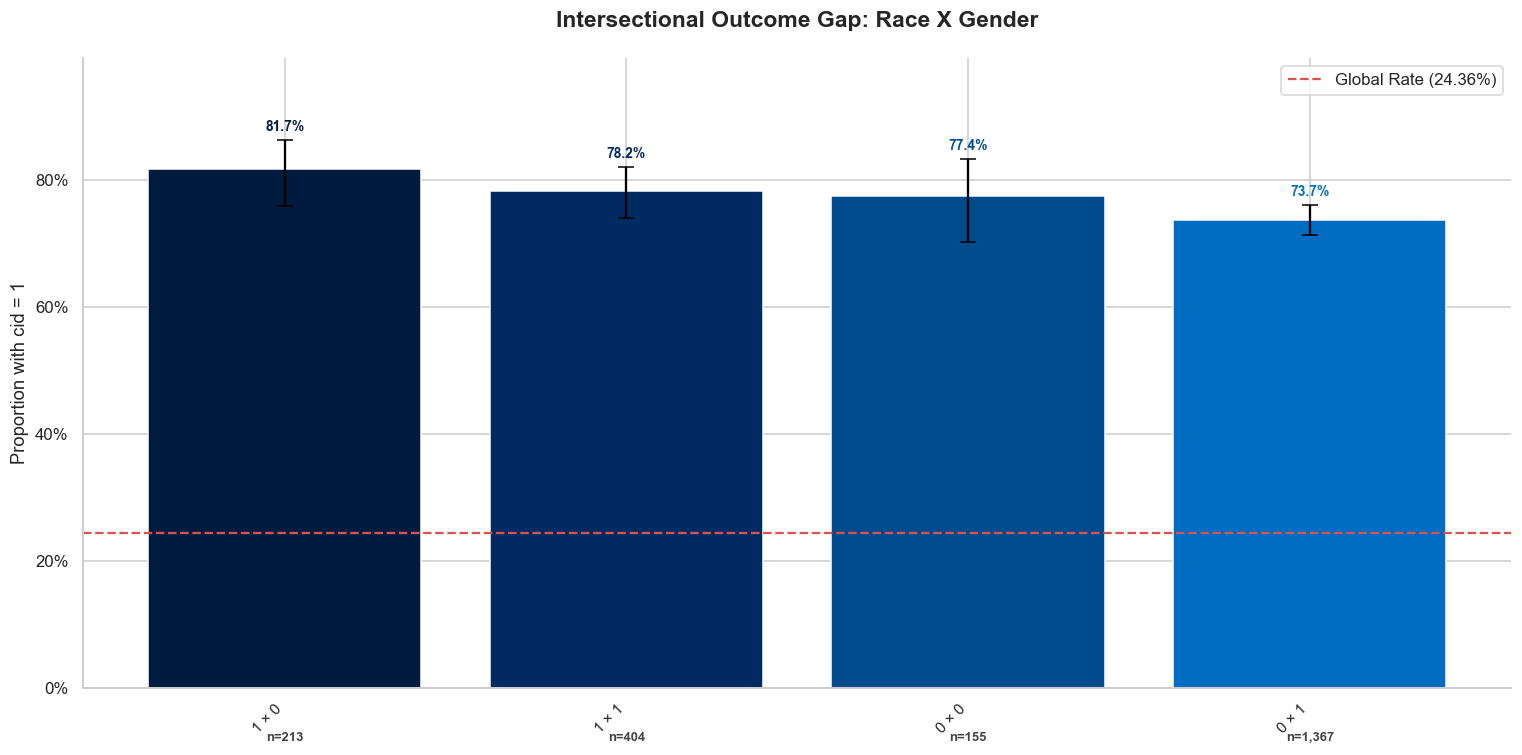

✓ Visualization generated and saved: race x homo


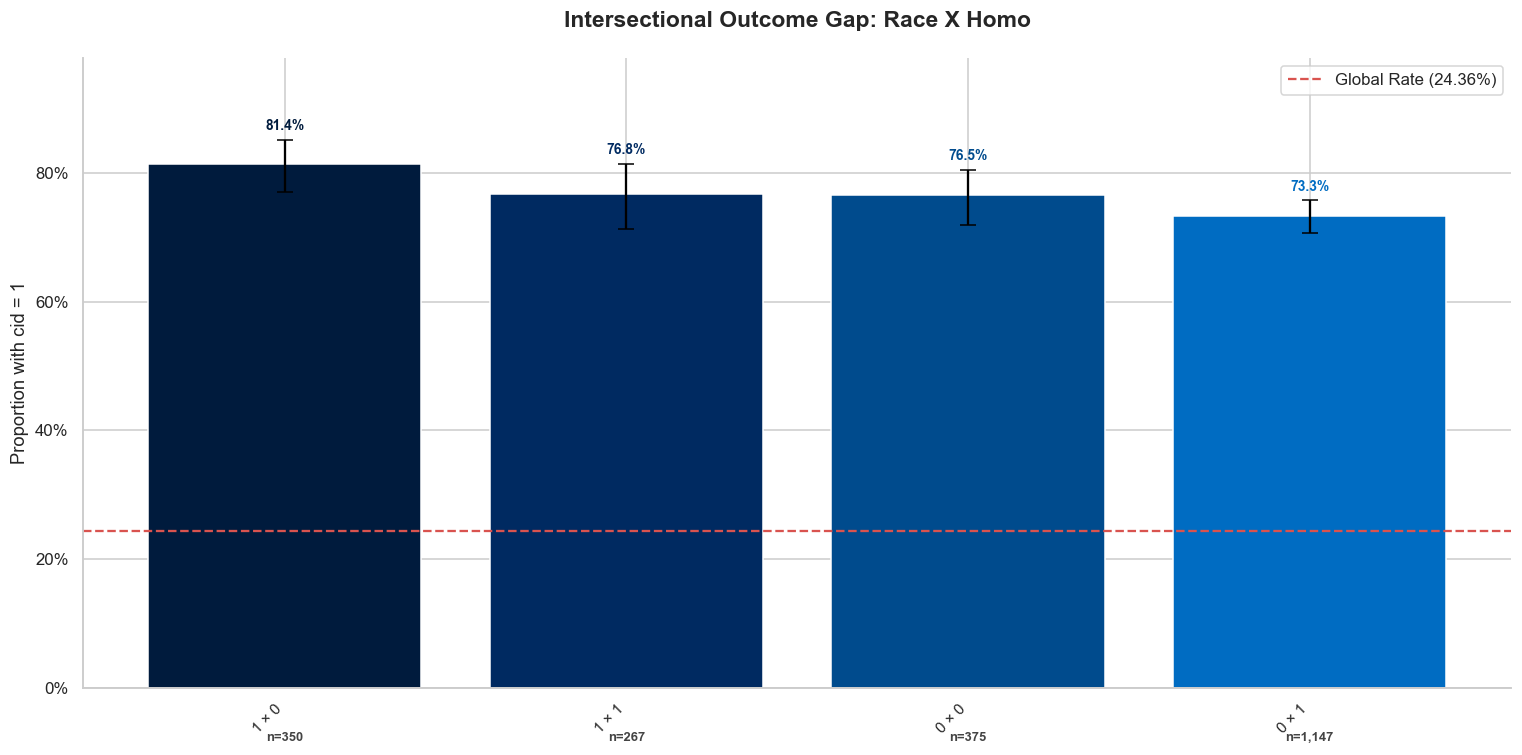

In [ ]:
# List of the two intersections that had a 100% score after scanning
PRIMARY_INTERSECTIONS = [
    "race x gender",
    "race x homo"
]

print(f"{'='*75}")
print(f"  LABEL DISTRIBUTION ANALYSIS (cid = 0) — {DATASET_NAME}")
print(f"{'='*75}")

global_rate = df_pp[TARGET_COL].mean()
print(f"  Global Favorable Rate: {global_rate:.4f} ({global_rate:.2%})\n")

for intersection in PRIMARY_INTERSECTIONS:
    attrs = intersection.split(' x ')
    col_name = '_x_'.join(attrs)

    df_pp[col_name] = df_pp[attrs].astype(str).apply(lambda row: ' × '.join(row.values), axis=1)

    label_stats = subgroup_label_stats(df_pp, col_name, TARGET_COL, FAVORABLE_LABEL)
    
    fig, ax = plt.subplots(figsize=(14,7))

    # Sorting by favorable rate to show the "Privilege scaling"
    label_stats = label_stats.sort_values("favorable_rate", ascending=False)

    x = range(len(label_stats))
    palette_cycle = [LAB_PALETTE_CATEGORICAL[i % len(LAB_PALETTE_CATEGORICAL)] for i in range(len(label_stats))]

    bars = ax.bar(x, label_stats["favorable_rate"], color=palette_cycle, edgecolor="white", zorder=2)
    ax.errorbar(
        x, label_stats["favorable_rate"],
        yerr=[label_stats["favorable_rate"] - label_stats["IC_low"],
        label_stats["IC_high"] - label_stats["favorable_rate"]],
        fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)

    # Global Reference
    ax.axhline(global_rate, color="#d9534f", linestyle="--", linewidth=1.5, 
        label=f"Global Rate ({global_rate:.2%})")

    # Academic formatting
    ax.set_xticks(x)
    ax.set_xticklabels(label_stats["subgroup"], rotation=45, ha="right", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f"Intersectional Outcome Gap: {intersection.title()}", fontsize=15, fontweight='bold', pad=20)
    ax.set_ylabel("Proportion with cid = 0", fontsize=12)
    ax.set_ylim(0, max(label_stats["IC_high"].max(), global_rate) * 1.15)
    ax.legend(loc='upper right')

    for i, (idx, row) in enumerate(label_stats.iterrows()):
        # N Label (under x axis)
        ax.text(i, -0.07, f"n={int(row['n']):,}", 
                ha="center", va="top", 
                fontsize=8.5, fontweight='bold', 
                color="#444444", 
                transform=ax.get_xaxis_transform())
        
        # PCT over error bar
        # We use row["IC_high"] + offset to avoid touching the line
        percentage = f"{row['favorable_rate']:.1%}"
        ax.text(i, row['IC_high'] + 0.01, percentage, 
                ha='center', va='bottom', 
                fontsize=9, fontweight='bold', 
                color=palette_cycle[i]) # Usa a mesma cor da barra para semântica
        
    plt.tight_layout()

    # Saving
    fig_name = f"{DATASET_NAME.replace(' ','_')}_block3_{col_name}_distribution.png"
    save_path = DATA_PATH / f"intersectional_analysis/{file_name}"
    plt.savefig(save_path, bbox_inches="tight", dpi=300)

    print(f"✓ Visualization generated and saved: {intersection}")
    plt.show()